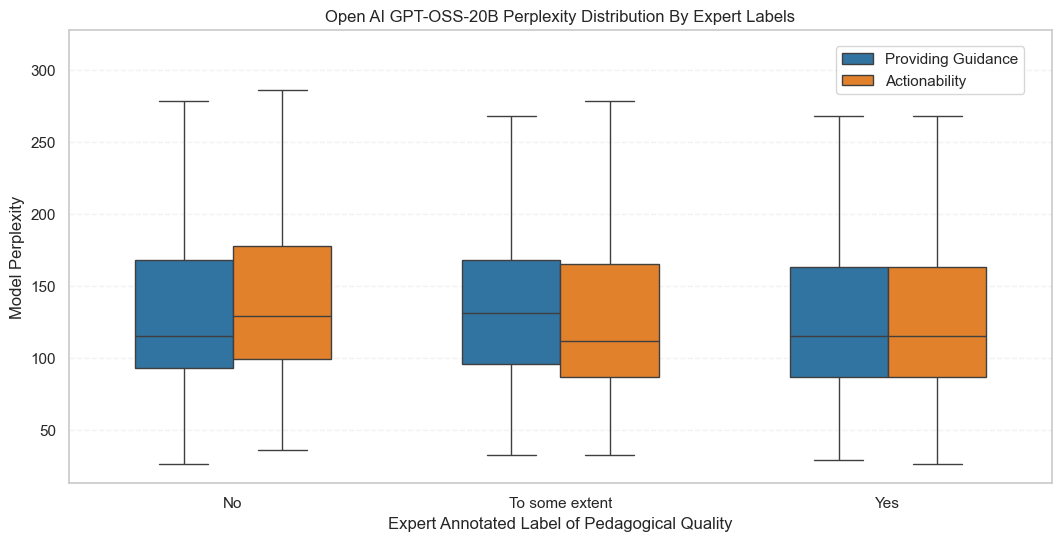

In [15]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
PATH = "/Users/ppit/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Desktop/IndirectScore/asset/data/logprob_results"
MODEL = [
    'google_gemma-3-12b-it',
    'meta-llama_Llama-3.2-3B-Instruct',
    "microsoft_Phi-4-reasoning-plus",
    "openai_gpt-oss-20b",
    "Qwen_Qwen3-30B-A3B-Instruct-2507-FP8"
 ]

model = MODEL[3]
# --- Config ---
JSON_PATH_CANDIDATES = [
    Path(PATH) / model / 'regular.json',
]

# Choose what goes on Y (numeric).
X_FIELD = 'perplexity'  # try: 'avg_log_prob', 'total_log_prob', or 'perplexity'
MODEL_FILTER = None       # e.g. set to an exact model name inside the json to filter
COLOR_BY_MODEL = True     # not used in this view, but kept for compatibility

def _find_existing_path(candidates: list[Path]) -> Path:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find regular.json. Tried:\n' + '\n'.join(str(p.resolve()) for p in candidates))

json_path = _find_existing_path(JSON_PATH_CANDIDATES)
with open(json_path, 'r') as f:
    data = json.load(f)

def _guidance_to_num(label: str) -> float:
    if label is None:
        return float('nan')
    normalized = str(label).strip().lower()
    mapping = {
        'no': 0.0,
        'to some extent': 0.5,
        'yes': 1.0,
    }
    if normalized in mapping:
        return mapping[normalized]
    raise ValueError(f'Unknown label: {label!r}')

rows = []
for item in data:
    conv_id = item.get('conversation_id')
    models = item.get('models', {}) or {}
    for model_name, payload in models.items():
        if MODEL_FILTER and model_name != MODEL_FILTER:
            continue
        rows.append({
            'conversation_id': conv_id,
            'model': model_name,
            'actionability_num': _guidance_to_num(payload.get('actionability')),
            'guidance_num': _guidance_to_num(payload.get('providing_guidance')),
            'avg_log_prob': payload.get('avg_log_prob'),
            'total_log_prob': payload.get('total_log_prob'),
            'perplexity': payload.get('perplexity'),
        })

df = pd.DataFrame(rows)
df = df.dropna(subset=[X_FIELD, 'guidance_num', 'actionability_num'])
df[X_FIELD] = pd.to_numeric(df[X_FIELD], errors='coerce')
df = df.dropna(subset=[X_FIELD])

# --- Single combined figure (blue vs orange) ---
tick_order = ['No', 'To some extent', 'Yes']
label_map = {0.0: 'No', 0.5: 'To some extent', 1.0: 'Yes'}

long_df = pd.DataFrame({
    'expert_label_num': pd.concat([df['guidance_num'], df['actionability_num']], ignore_index=True),
    'metric': (['Providing Guidance'] * len(df)) + (['Actionability'] * len(df)),
    X_FIELD: pd.concat([df[X_FIELD], df[X_FIELD]], ignore_index=True),
})
long_df = long_df.dropna(subset=['expert_label_num', X_FIELD])
long_df['expert_label'] = long_df['expert_label_num'].map(label_map)
long_df['expert_label'] = pd.Categorical(long_df['expert_label'], categories=tick_order, ordered=True)

palette = {
    'Providing Guidance': '#1f77b4',  # blue
    'Actionability': '#ff7f0e',       # orange
}

# Slightly taller so the legend can fit inside without forcing a huge y-range
fig, ax = plt.subplots(figsize=(10.5, 5.3), constrained_layout=True)
sns.boxplot(
    data=long_df,
    x='expert_label',
    y=X_FIELD,
    hue='metric',
    order=tick_order,
    palette=palette,
    showfliers=False,
    width=0.6,
    dodge=True,
    ax=ax,
 )

ax.set_xlabel('Expert Annotated Label of Pedagogical Quality')
ax.set_ylabel("Model Perplexity")
ax.grid(True, axis='y', linestyle='--', alpha=0.25)
ax.set_title('Open AI GPT-OSS-20B Perplexity Distribution By Expert Labels')

# Add a small amount of headroom based on the plotted limits (not raw outliers)
y0, y1 = ax.get_ylim()
ax.set_ylim(y0, y1 + 0.10 * (y1 - y0))

# Legend: inside, top-right
ax.legend(title='', frameon=True, loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.show()